In [27]:
import pandas as pd
from scipy import stats as sp_stats

In [28]:
player_season = pd.read_csv('nba_player_season_analysis.csv')
team = pd.read_csv('team_stats.csv')

In [29]:
## Adding playoff team column to team dataframe
playoff_team ={'2022-23': ['DEN', 'MIN', 'PHX', 'LAC', 'GSW', 'SAC', 'MEM', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ATL', 'PHI', 'BKN'],
                '2023-24': ['DEN', 'MIN', 'DAL', 'LAC', 'PEL', 'OKC', 'PHX', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ORL', 'PHI', 'IND'],
                '2024-25': ['DEN', 'MIN', 'MEM', 'LAC', 'GSW', 'OKC', 'HOU', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ORL', 'IND', 'DET'],
                '2025-26': ['DEN', 'MIN', 'OKC', 'LAC', 'SAS', 'POR', 'PHX', 'LAL', 'ORL', 'DET', 'CLE', 'NYK', 'BOS', 'TOR', 'PHI', 'ATL']}
team['playoff_team'] = team.apply(lambda row: row['team'] in playoff_team.get(row['season'], []), axis=1)


In [30]:
## Joining player_season and team dataframes on season and team columns
player_analysis = player_season.merge(team[['season', 'team', 'playoff_team']],
    on=['season', 'team'],
    how='left')

In [31]:
## Player stats on playoff vs non-playoff teams  overall


player_analysis[player_analysis['minutes_pg']>15].groupby('playoff_team')[
    ['points_pg', 
     'rebounds_pg', 
     'assists_pg', 
     'ts_pct', 
     'effective_fg_pct', 
     'usage_rate', 
     'ast_pct', 
     'reb_pct',
     'tov_pct']].mean().round(4)

,points_pg,rebounds_pg,assists_pg,ts_pct,effective_fg_pct,usage_rate,ast_pct,reb_pct,tov_pct
playoff_team,,,,,,,,,
False,11.6039,4.4313,2.7142,0.5684,0.5372,0.1886,0.1567,0.0967,0.1256
True,12.7404,4.7156,2.9478,0.5864,0.5571,0.1888,0.1569,0.1039,0.1177


In [32]:
## Player scoring and efficiency metrics for playoff vs non-playoff teams

filtered_players = player_analysis[player_analysis['minutes_pg'] > 15]
playoff_players = filtered_players[(filtered_players['playoff_team'] == True)]
non_playoff_players = filtered_players[(filtered_players['playoff_team'] == False)]
metrics = ['points_pg', 'ts_pct', 'effective_fg_pct', 'usage_rate', 'tov_pct']
test_results = []

for metric in metrics:
    playoff_vec = playoff_players[metric]
    non_playoff_vec = non_playoff_players[metric]
    
    t_stat, p_val = sp_stats.ttest_ind(playoff_vec, non_playoff_vec)
    
    test_results.append({
        'Metric': metric,
        'Playoff Mean': playoff_vec.mean(),
        'Non-Playoff Mean': non_playoff_vec.mean(),
        'Mean Diff': playoff_vec.mean() - non_playoff_vec.mean(),
        'p-value': p_val,
        'Statistically Significant': p_val < 0.05
    })

results_df = pd.DataFrame(test_results).round(4)
print(results_df)




             Metric  Playoff Mean  Non-Playoff Mean  Mean Diff  p-value  \
0         points_pg       12.7404           11.6039     1.1366   0.0005   
1            ts_pct        0.5864            0.5684     0.0180   0.0000   
2  effective_fg_pct        0.5571            0.5372     0.0199   0.0000   
3        usage_rate        0.1888            0.1886     0.0002   0.9422   
4           tov_pct        0.1177            0.1256    -0.0079   0.0001   

   Statistically Significant  
0                       True  
1                       True  
2                       True  
3                      False  
4                       True  


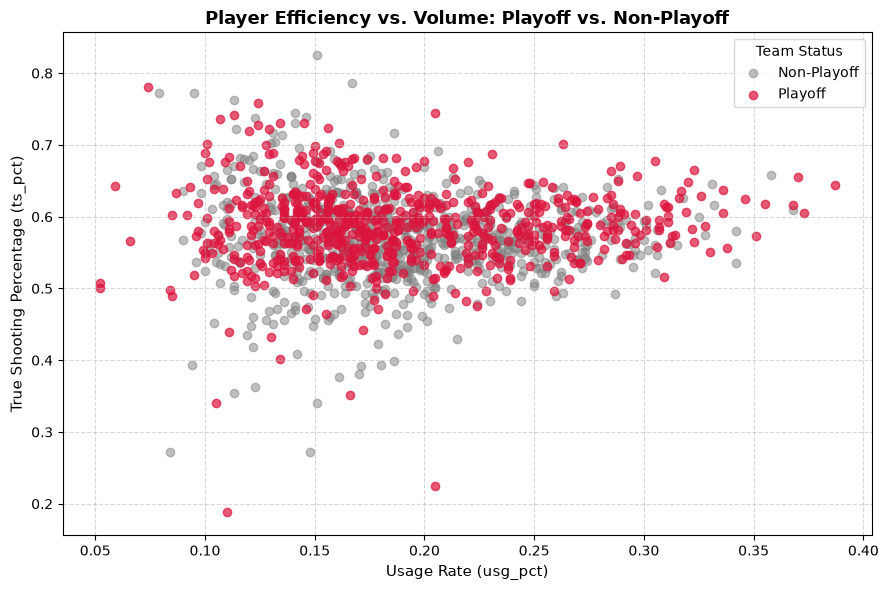

In [33]:
## Plotting player efficiency vs. volume for playoff vs non-playoff teams

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.scatter(non_playoff_players['usage_rate'], non_playoff_players['ts_pct'], color='gray', alpha=0.5, label='Non-Playoff')
plt.scatter(playoff_players['usage_rate'], playoff_players['ts_pct'], color='crimson', alpha=0.7, label='Playoff')

plt.title('Player Efficiency vs. Volume: Playoff vs. Non-Playoff', fontsize=13, fontweight='bold')
plt.xlabel('Usage Rate (usg_pct)', fontsize=11)
plt.ylabel('True Shooting Percentage (ts_pct)', fontsize=11)
plt.legend(title='Team Status')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [34]:
## offensive and defensive rating and net_rating metrics for playoff vs non-playoff teams

playoff_team = team[team['playoff_team'] == True]
non_playoff_team = team[team['playoff_team'] == False]
team_metrics = ['off_rating_est', 'def_rating_est', 'net_rating']
team_results = []
for metric in team_metrics:
    playoff_vec = playoff_team[metric]
    non_playoff_vec = non_playoff_team[metric]
    
    # Run the two-sample t-test
    t_stat, p_val = sp_stats.ttest_ind(playoff_vec, non_playoff_vec)
    
    team_results.append({
        'Metric': metric,
        'Playoff Mean': playoff_vec.mean(),
        'Non-Playoff Mean': non_playoff_vec.mean(),
        'Mean Diff': playoff_vec.mean() - non_playoff_vec.mean(),
        'p-value': p_val,
        'Statistically Significant': p_val < 0.05
    })
team_results_df = pd.DataFrame(team_results).round(4)
print(team_results_df)

           Metric  Playoff Mean  Non-Playoff Mean  Mean Diff  p-value  \
0  off_rating_est      114.1439          110.2551     3.8888      0.0   
1  def_rating_est      110.5494          114.2279    -3.6786      0.0   
2      net_rating        3.5945           -3.9729     7.5674      0.0   

   Statistically Significant  
0                       True  
1                       True  
2                       True  


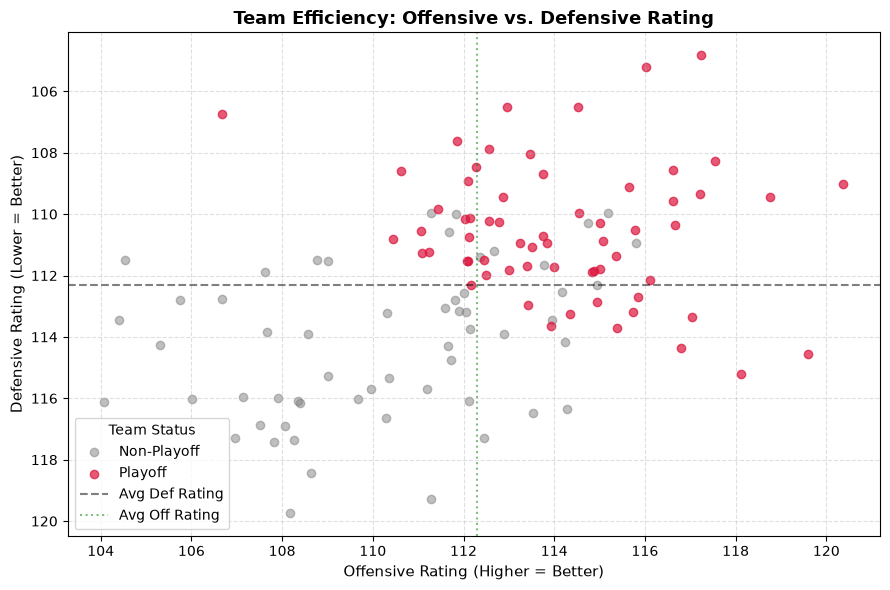

In [35]:
## Plotting offensive vs defensive rating for playoff vs non-playoff teams

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.scatter(non_playoff_team['off_rating_est'], non_playoff_team['def_rating_est'], color='gray', alpha=0.5, label='Non-Playoff')
plt.scatter(playoff_team['off_rating_est'], playoff_team['def_rating_est'], color='crimson',alpha=0.7, label='Playoff')
avg_def = team['def_rating_est'].mean()
avg_off = team['off_rating_est'].mean()
plt.axhline(y=avg_def, color='black', linestyle='--', alpha=0.5, label='Avg Def Rating')
plt.axvline(x=avg_off, color='green', linestyle=':', alpha=0.5, label='Avg Off Rating')
plt.gca().invert_yaxis()

plt.title('Team Efficiency: Offensive vs. Defensive Rating', fontsize=13, fontweight='bold')
plt.xlabel('Offensive Rating (Higher = Better)', fontsize=11)
plt.ylabel('Defensive Rating (Lower = Better)', fontsize=11)
plt.legend(title='Team Status', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [36]:
## Comparing average assists and turnovers for playoff vs non-playoff teams

playoff_team = team[team['playoff_team'] == True]
non_playoff_team = team[team['playoff_team'] == False]
metrics = ['avg_apg', 'avg_to']
team_results = []
for metric in metrics:
    playoff_vec = playoff_team[metric]
    non_playoff_vec = non_playoff_team[metric]

    t_stat, p_val = sp_stats.ttest_ind(playoff_vec, non_playoff_vec)
    team_results.append({
        'Metric': metric,
        'Playoff_mean':playoff_vec.mean(),
        'Non_playoff_mean':non_playoff_vec.mean(),
        'Mean_diff':playoff_vec.mean() - non_playoff_vec.mean(),
        'p-value': p_val,
        'Statistically_significant': p_val < 0.05
        })

print(pd.DataFrame(team_results).round(4))

    Metric  Playoff_mean  Non_playoff_mean  Mean_diff  p-value  \
0  avg_apg       26.5393           26.0764     0.4629   0.1935   
1   avg_to       13.7574           14.5357    -0.7783   0.0001   

   Statistically_significant  
0                      False  
1                       True  


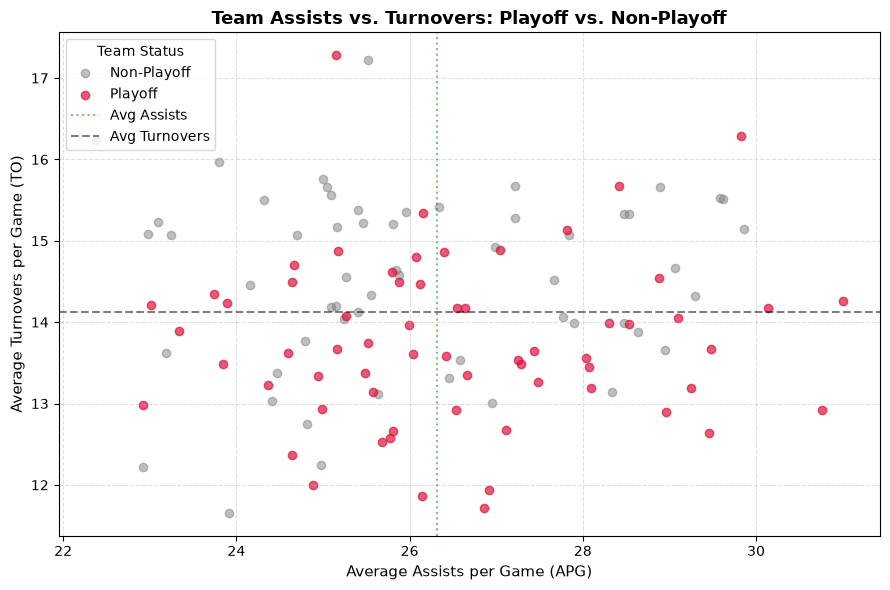

In [37]:
## Plotting average assists vs turnovers for playoff vs non-playoff teams

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

plt.scatter(non_playoff_team['avg_apg'], non_playoff_team['avg_to'], color='gray', alpha=0.5, label='Non-Playoff')
plt.scatter(playoff_team['avg_apg'], playoff_team['avg_to'], color='crimson', alpha=0.7, label='Playoff')

plt.axvline(team['avg_apg'].mean(), color='green', linestyle=':', alpha=0.5, label='Avg Assists')
plt.axhline(team['avg_to'].mean(), color='black', linestyle='--', alpha=0.5, label='Avg Turnovers')

plt.title('Team Assists vs. Turnovers: Playoff vs. Non-Playoff', fontsize=13, fontweight='bold')
plt.xlabel('Average Assists per Game (APG)', fontsize=11)
plt.ylabel('Average Turnovers per Game (TO)', fontsize = 11)

plt.legend(title='Team Status', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



In [38]:
## Comparing average offensive and defensive rebounds for playoff vs non-playoff teams

playoff_team = team[team['playoff_team'] == True]
non_playoff_team = team[team['playoff_team'] == False]

metrics = ['avg_defensive_rebounds', 'avg_offensive_rebounds']
team_results = []
for metric in metrics:
    playoff_avg = playoff_team[metric].mean()
    non_playoff_avg = non_playoff_team[metric].mean()

    playoff_vec = playoff_team[metric]
    non_playoff_vec = non_playoff_team[metric]

    t_stat, p_val = sp_stats.ttest_ind(playoff_vec, non_playoff_vec)

    team_results.append({
        'Metric':metric,
        'Playoff_mean':playoff_avg,
        'Non_playoff_mean':non_playoff_avg,
        'Mean_diff':playoff_avg - non_playoff_avg,
        'p-value':p_val,
        'Statistically_significant': p_val < 0.05
    })

print(pd.DataFrame(team_results).round(4))

                   Metric  Playoff_mean  Non_playoff_mean  Mean_diff  p-value  \
0  avg_defensive_rebounds       33.2259           32.4221     0.8038   0.0020   
1  avg_offensive_rebounds       10.6827           11.0796    -0.3969   0.1125   

   Statistically_significant  
0                       True  
1                      False  


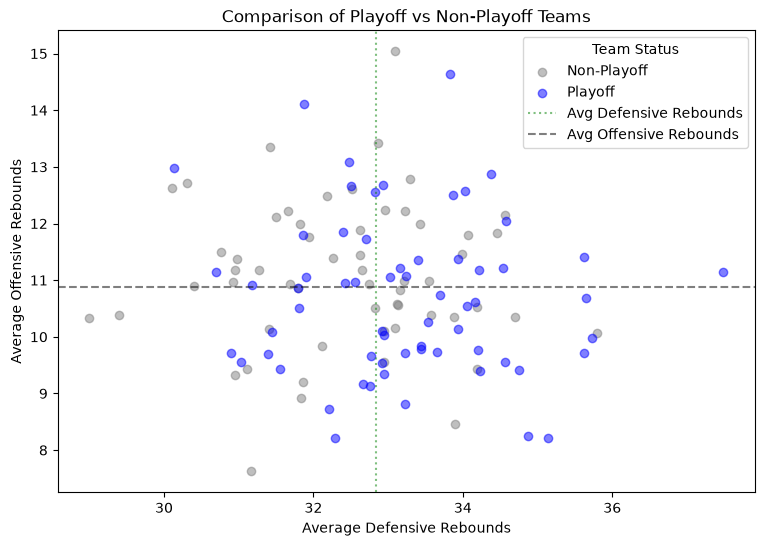

In [39]:
## Plotting average offensive and defensive rebounds for playoff vs non-playoff teams

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

plt.scatter(non_playoff_team['avg_defensive_rebounds'], non_playoff_team['avg_offensive_rebounds'], color='gray', alpha=0.5, label='Non-Playoff')
plt.scatter(playoff_team['avg_defensive_rebounds'], playoff_team['avg_offensive_rebounds'], color='blue', alpha=0.5, label='Playoff')

plt.axvline(team['avg_defensive_rebounds'].mean(), color ='green', linestyle=':', alpha=0.5, label = 'Avg Defensive Rebounds')
plt.axhline(team['avg_offensive_rebounds'].mean(), color='black', linestyle='--', alpha=0.5, label='Avg Offensive Rebounds')

plt.xlabel('Average Defensive Rebounds')
plt.ylabel('Average Offensive Rebounds')
plt.title('Comparison of Playoff vs Non-Playoff Teams')
plt.legend(title='Team Status', loc='upper right')
plt.show()